# TS4: Primeras nociones de estimación espectral

En esta tarea se estudia la estimación espectral de una señal senoidal contaminada con ruido gaussiano.

Se analizarán los estimadores de amplitud y frecuencia utilizando cuatro ventanas diferentes:

- Rectangular
- Flattop
- Blackman-Harris
- Hann

Para cada caso se realizarán 200 realizaciones de 1000 muestras y se analizarán dos niveles de relación señal-ruido: SNR = 3 dB y SNR = 10 dB.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows

plt.close('all')

# Parámetros
N = 1000
M = 200
a0 = np.sqrt(2)

n = np.arange(N)
k = np.arange(N)

omega0 = np.pi/2
k0 = int(np.round(omega0 * N / (2*np.pi)))

Ps = a0**2 / 2

# Eje de bins positivos
k_pos = k[:N//2]

## Ventanas analizadas

Se consideran las tres ventanas indicadas en la consigna: rectangular, Flattop y Blackman-Harris. Como cuarta ventana se selecciona la ventana Hann.

In [2]:
w_rect = np.ones(N)
w_flattop = windows.flattop(N)
w_blackmanharris = windows.blackmanharris(N)
w_hann = windows.hann(N)

## Experimento para SNR = 3 dB

Para cada una de las 200 realizaciones se genera un nuevo valor aleatorio de desplazamiento frecuencial y una nueva realización de ruido gaussiano.

A continuación se aplican las cuatro ventanas y se obtienen las estimaciones de amplitud y frecuencia a partir de la FFT.

In [3]:
SNR_dB = 3
sigma = np.sqrt(Ps / (10**(SNR_dB/10)))

# Listas para las estimaciones de amplitud
a_rect_3 = []
a_flattop_3 = []
a_blackmanharris_3 = []
a_hann_3 = []

# Listas para las estimaciones de frecuencia
f_rect_3 = []
f_flattop_3 = []
f_blackmanharris_3 = []
f_hann_3 = []

# Frecuencia real de cada realización
f_real_3 = []

for i in range(M):

    fr = np.random.uniform(-2, 2)
    omega1 = omega0 + fr * 2*np.pi/N

    k_real = k0 + fr
    f_real_3.append(k_real)

    x = a0 * np.sin(omega1*n)

    na = np.random.normal(0, sigma, N)
    x_ruido = x + na


    # Ventana rectangular
    x_rect = x_ruido * w_rect

    X_rect = np.fft.fft(x_rect)
    X_rect_mod = np.abs(X_rect)
    X_rect_pos = X_rect_mod[:N//2]

    X_rect_norm = (2 / np.sum(w_rect)) * X_rect_pos

    a_rect_3.append(X_rect_norm[k0])

    indice_max_rect = np.argmax(X_rect_pos)
    f_rect_3.append(k_pos[indice_max_rect])


    # Ventana Flattop
    x_flattop = x_ruido * w_flattop

    X_flattop = np.fft.fft(x_flattop)
    X_flattop_mod = np.abs(X_flattop)
    X_flattop_pos = X_flattop_mod[:N//2]

    X_flattop_norm = (2 / np.sum(w_flattop)) * X_flattop_pos

    a_flattop_3.append(X_flattop_norm[k0])

    indice_max_flattop = np.argmax(X_flattop_pos)
    f_flattop_3.append(k_pos[indice_max_flattop])


    # Ventana Blackman-Harris
    x_blackmanharris = x_ruido * w_blackmanharris

    X_blackmanharris = np.fft.fft(x_blackmanharris)
    X_blackmanharris_mod = np.abs(X_blackmanharris)
    X_blackmanharris_pos = X_blackmanharris_mod[:N//2]

    X_blackmanharris_norm = (
        2 / np.sum(w_blackmanharris)
    ) * X_blackmanharris_pos

    a_blackmanharris_3.append(X_blackmanharris_norm[k0])

    indice_max_blackmanharris = np.argmax(X_blackmanharris_pos)
    f_blackmanharris_3.append(k_pos[indice_max_blackmanharris])


    # Ventana Hann
    x_hann = x_ruido * w_hann

    X_hann = np.fft.fft(x_hann)
    X_hann_mod = np.abs(X_hann)
    X_hann_pos = X_hann_mod[:N//2]

    X_hann_norm = (2 / np.sum(w_hann)) * X_hann_pos

    a_hann_3.append(X_hann_norm[k0])

    indice_max_hann = np.argmax(X_hann_pos)
    f_hann_3.append(k_pos[indice_max_hann])

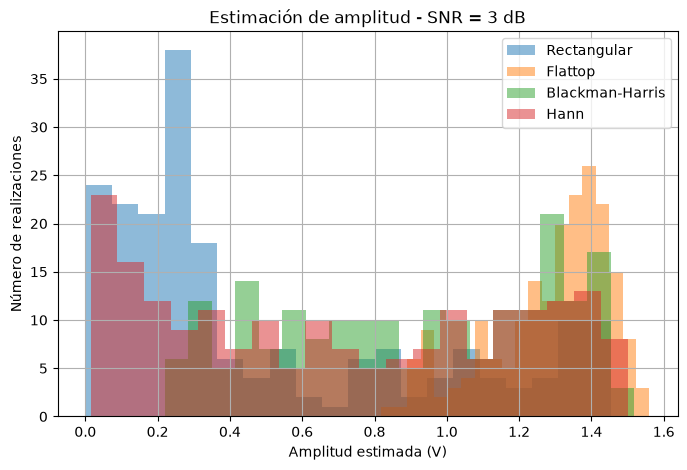

In [4]:
plt.figure(figsize=(8, 5))

plt.hist(a_rect_3, bins=20, alpha=0.5, label="Rectangular")
plt.hist(a_flattop_3, bins=20, alpha=0.5, label="Flattop")
plt.hist(a_blackmanharris_3, bins=20, alpha=0.5, label="Blackman-Harris")
plt.hist(a_hann_3, bins=20, alpha=0.5, label="Hann")

plt.xlabel("Amplitud estimada (V)")
plt.ylabel("Número de realizaciones")
plt.title("Estimación de amplitud - SNR = 3 dB")
plt.legend()
plt.grid()
plt.show()

## Experimento para SNR = 10 dB

Se repite el mismo procedimiento aumentando la relación señal-ruido a 10 dB. Al aumentar la SNR disminuye la potencia relativa del ruido presente en la señal.

In [5]:
SNR_dB = 10
sigma = np.sqrt(Ps / (10**(SNR_dB/10)))

# Listas para las estimaciones de amplitud
a_rect_10 = []
a_flattop_10 = []
a_blackmanharris_10 = []
a_hann_10 = []

# Listas para las estimaciones de frecuencia
f_rect_10 = []
f_flattop_10 = []
f_blackmanharris_10 = []
f_hann_10 = []

# Frecuencia real de cada realización
f_real_10 = []

for i in range(M):

    fr = np.random.uniform(-2, 2)
    omega1 = omega0 + fr * 2*np.pi/N

    k_real = k0 + fr
    f_real_10.append(k_real)

    x = a0 * np.sin(omega1*n)

    na = np.random.normal(0, sigma, N)
    x_ruido = x + na


    # Ventana rectangular
    x_rect = x_ruido * w_rect

    X_rect = np.fft.fft(x_rect)
    X_rect_mod = np.abs(X_rect)
    X_rect_pos = X_rect_mod[:N//2]

    X_rect_norm = (2 / np.sum(w_rect)) * X_rect_pos

    a_rect_10.append(X_rect_norm[k0])

    indice_max_rect = np.argmax(X_rect_pos)
    f_rect_10.append(k_pos[indice_max_rect])


    # Ventana Flattop
    x_flattop = x_ruido * w_flattop

    X_flattop = np.fft.fft(x_flattop)
    X_flattop_mod = np.abs(X_flattop)
    X_flattop_pos = X_flattop_mod[:N//2]

    X_flattop_norm = (2 / np.sum(w_flattop)) * X_flattop_pos

    a_flattop_10.append(X_flattop_norm[k0])

    indice_max_flattop = np.argmax(X_flattop_pos)
    f_flattop_10.append(k_pos[indice_max_flattop])


    # Ventana Blackman-Harris
    x_blackmanharris = x_ruido * w_blackmanharris

    X_blackmanharris = np.fft.fft(x_blackmanharris)
    X_blackmanharris_mod = np.abs(X_blackmanharris)
    X_blackmanharris_pos = X_blackmanharris_mod[:N//2]

    X_blackmanharris_norm = (
        2 / np.sum(w_blackmanharris)
    ) * X_blackmanharris_pos

    a_blackmanharris_10.append(X_blackmanharris_norm[k0])

    indice_max_blackmanharris = np.argmax(X_blackmanharris_pos)
    f_blackmanharris_10.append(k_pos[indice_max_blackmanharris])


    # Ventana Hann
    x_hann = x_ruido * w_hann

    X_hann = np.fft.fft(x_hann)
    X_hann_mod = np.abs(X_hann)
    X_hann_pos = X_hann_mod[:N//2]

    X_hann_norm = (2 / np.sum(w_hann)) * X_hann_pos

    a_hann_10.append(X_hann_norm[k0])

    indice_max_hann = np.argmax(X_hann_pos)
    f_hann_10.append(k_pos[indice_max_hann])

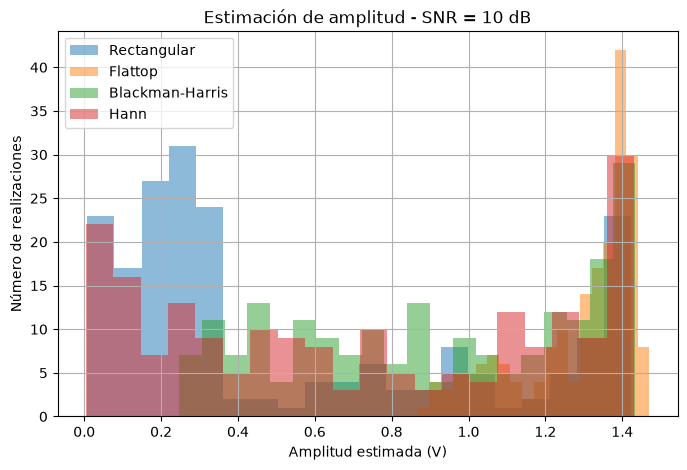

In [6]:
plt.figure(figsize=(8, 5))

plt.hist(a_rect_10, bins=20, alpha=0.5, label="Rectangular")
plt.hist(a_flattop_10, bins=20, alpha=0.5, label="Flattop")
plt.hist(a_blackmanharris_10, bins=20, alpha=0.5, label="Blackman-Harris")
plt.hist(a_hann_10, bins=20, alpha=0.5, label="Hann")

plt.xlabel("Amplitud estimada (V)")
plt.ylabel("Número de realizaciones")
plt.title("Estimación de amplitud - SNR = 10 dB")
plt.legend()
plt.grid()
plt.show()

### Análisis cualitativo

Comparando los histogramas obtenidos para SNR = 3 dB y SNR = 10 dB se observa que la ventana utilizada influye significativamente en la estimación de amplitud.

La ventana **Flattop** presenta una mayor concentración de estimaciones próximas a la amplitud real de la señal, mientras que la ventana **rectangular** presenta una mayor dispersión y un mayor número de estimaciones alejadas de dicho valor. Las ventanas **Hann** y **Blackman-Harris** presentan un comportamiento intermedio.

Al aumentar la SNR de 3 dB a 10 dB disminuye la influencia relativa del ruido y las estimaciones tienden a ser más estables.

De forma cualitativa, la ventana Flattop presenta el mejor comportamiento para la estimación de amplitud. Estas observaciones se analizarán cuantitativamente mediante el cálculo del sesgo y la varianza de los estimadores.

## Sesgo y varianza de los estimadores

El sesgo del estimador de amplitud se calcula como:

$$
s_a = E\{\hat{a}\} - a_0
$$

mientras que su varianza se aproxima experimentalmente mediante:

$$
v_a = \frac{1}{M}\sum_{j=0}^{M-1}
\left(\hat{a}_j-\hat{\mu}_a\right)^2
$$

Para el estimador de frecuencia se calcula el error entre la frecuencia estimada y la frecuencia verdadera de cada realización:

$$
e_{f,j} = \hat{f}_j - f_j
$$

A partir de estos errores se calculan experimentalmente el sesgo y la varianza del estimador de frecuencia.

In [7]:
sesgo_a_rect_3 = np.mean(a_rect_3) - a0
sesgo_a_flattop_3 = np.mean(a_flattop_3) - a0
sesgo_a_blackmanharris_3 = np.mean(a_blackmanharris_3) - a0
sesgo_a_hann_3 = np.mean(a_hann_3) - a0

var_a_rect_3 = np.var(a_rect_3)
var_a_flattop_3 = np.var(a_flattop_3)
var_a_blackmanharris_3 = np.var(a_blackmanharris_3)
var_a_hann_3 = np.var(a_hann_3)

print("\nESTIMACIÓN DE AMPLITUD - SNR = 3 dB")
print("-" * 57)
print(f"{'Ventana':<20} {'Sesgo':>15} {'Varianza':>15}")
print("-" * 57)

print(f"{'Rectangular':<20} {sesgo_a_rect_3:>15.6f} {var_a_rect_3:>15.6f}")
print(f"{'Flattop':<20} {sesgo_a_flattop_3:>15.6f} {var_a_flattop_3:>15.6f}")
print(f"{'Blackman-Harris':<20} {sesgo_a_blackmanharris_3:>15.6f} {var_a_blackmanharris_3:>15.6f}")
print(f"{'Hann':<20} {sesgo_a_hann_3:>15.6f} {var_a_hann_3:>15.6f}")

print("-" * 57)


ESTIMACIÓN DE AMPLITUD - SNR = 3 dB
---------------------------------------------------------
Ventana                        Sesgo        Varianza
---------------------------------------------------------
Rectangular                -0.928758        0.195891
Flattop                    -0.126781        0.027534
Blackman-Harris            -0.505236        0.138330
Hann                       -0.715617        0.227054
---------------------------------------------------------


### Estimación de amplitud - SNR = 10 dB

In [8]:
sesgo_a_rect_10 = np.mean(a_rect_10) - a0
sesgo_a_flattop_10 = np.mean(a_flattop_10) - a0
sesgo_a_blackmanharris_10 = np.mean(a_blackmanharris_10) - a0
sesgo_a_hann_10 = np.mean(a_hann_10) - a0

var_a_rect_10 = np.var(a_rect_10)
var_a_flattop_10 = np.var(a_flattop_10)
var_a_blackmanharris_10 = np.var(a_blackmanharris_10)
var_a_hann_10 = np.var(a_hann_10)

print("\nESTIMACIÓN DE AMPLITUD - SNR = 10 dB")
print("-" * 57)
print(f"{'Ventana':<20} {'Sesgo':>15} {'Varianza':>15}")
print("-" * 57)

print(f"{'Rectangular':<20} {sesgo_a_rect_10:>15.6f} {var_a_rect_10:>15.6f}")
print(f"{'Flattop':<20} {sesgo_a_flattop_10:>15.6f} {var_a_flattop_10:>15.6f}")
print(f"{'Blackman-Harris':<20} {sesgo_a_blackmanharris_10:>15.6f} {var_a_blackmanharris_10:>15.6f}")
print(f"{'Hann':<20} {sesgo_a_hann_10:>15.6f} {var_a_hann_10:>15.6f}")

print("-" * 57)


ESTIMACIÓN DE AMPLITUD - SNR = 10 dB
---------------------------------------------------------
Ventana                        Sesgo        Varianza
---------------------------------------------------------
Rectangular                -0.879396        0.226792
Flattop                    -0.126222        0.023119
Blackman-Harris            -0.491474        0.142714
Hann                       -0.696230        0.245543
---------------------------------------------------------


### Estimación de frecuencia - SNR = 3 dB

In [9]:
f_real_3 = np.array(f_real_3)

f_rect_3 = np.array(f_rect_3)
f_flattop_3 = np.array(f_flattop_3)
f_blackmanharris_3 = np.array(f_blackmanharris_3)
f_hann_3 = np.array(f_hann_3)

# Error de estimación
error_f_rect_3 = f_rect_3 - f_real_3
error_f_flattop_3 = f_flattop_3 - f_real_3
error_f_blackmanharris_3 = f_blackmanharris_3 - f_real_3
error_f_hann_3 = f_hann_3 - f_real_3

# Sesgo
sesgo_f_rect_3 = np.mean(error_f_rect_3)
sesgo_f_flattop_3 = np.mean(error_f_flattop_3)
sesgo_f_blackmanharris_3 = np.mean(error_f_blackmanharris_3)
sesgo_f_hann_3 = np.mean(error_f_hann_3)

# Varianza
var_f_rect_3 = np.var(error_f_rect_3)
var_f_flattop_3 = np.var(error_f_flattop_3)
var_f_blackmanharris_3 = np.var(error_f_blackmanharris_3)
var_f_hann_3 = np.var(error_f_hann_3)

print("\nESTIMACIÓN DE FRECUENCIA - SNR = 3 dB")
print("-" * 57)
print(f"{'Ventana':<20} {'Sesgo':>15} {'Varianza':>15}")
print("-" * 57)

print(f"{'Rectangular':<20} {sesgo_f_rect_3:>15.6f} {var_f_rect_3:>15.6f}")
print(f"{'Flattop':<20} {sesgo_f_flattop_3:>15.6f} {var_f_flattop_3:>15.6f}")
print(f"{'Blackman-Harris':<20} {sesgo_f_blackmanharris_3:>15.6f} {var_f_blackmanharris_3:>15.6f}")
print(f"{'Hann':<20} {sesgo_f_hann_3:>15.6f} {var_f_hann_3:>15.6f}")

print("-" * 57)


ESTIMACIÓN DE FRECUENCIA - SNR = 3 dB
---------------------------------------------------------
Ventana                        Sesgo        Varianza
---------------------------------------------------------
Rectangular                 0.006899        0.083874
Flattop                     0.001899        0.176653
Blackman-Harris             0.011899        0.084091
Hann                        0.016899        0.083687
---------------------------------------------------------


### Estimación de frecuencia - SNR = 10 dB

In [10]:
f_real_10 = np.array(f_real_10)

f_rect_10 = np.array(f_rect_10)
f_flattop_10 = np.array(f_flattop_10)
f_blackmanharris_10 = np.array(f_blackmanharris_10)
f_hann_10 = np.array(f_hann_10)

# Error de estimación
error_f_rect_10 = f_rect_10 - f_real_10
error_f_flattop_10 = f_flattop_10 - f_real_10
error_f_blackmanharris_10 = f_blackmanharris_10 - f_real_10
error_f_hann_10 = f_hann_10 - f_real_10

# Sesgo
sesgo_f_rect_10 = np.mean(error_f_rect_10)
sesgo_f_flattop_10 = np.mean(error_f_flattop_10)
sesgo_f_blackmanharris_10 = np.mean(error_f_blackmanharris_10)
sesgo_f_hann_10 = np.mean(error_f_hann_10)

# Varianza
var_f_rect_10 = np.var(error_f_rect_10)
var_f_flattop_10 = np.var(error_f_flattop_10)
var_f_blackmanharris_10 = np.var(error_f_blackmanharris_10)
var_f_hann_10 = np.var(error_f_hann_10)

print("\nESTIMACIÓN DE FRECUENCIA - SNR = 10 dB")
print("-" * 57)
print(f"{'Ventana':<20} {'Sesgo':>15} {'Varianza':>15}")
print("-" * 57)

print(f"{'Rectangular':<20} {sesgo_f_rect_10:>15.6f} {var_f_rect_10:>15.6f}")
print(f"{'Flattop':<20} {sesgo_f_flattop_10:>15.6f} {var_f_flattop_10:>15.6f}")
print(f"{'Blackman-Harris':<20} {sesgo_f_blackmanharris_10:>15.6f} {var_f_blackmanharris_10:>15.6f}")
print(f"{'Hann':<20} {sesgo_f_hann_10:>15.6f} {var_f_hann_10:>15.6f}")

print("-" * 57)


ESTIMACIÓN DE FRECUENCIA - SNR = 10 dB
---------------------------------------------------------
Ventana                        Sesgo        Varianza
---------------------------------------------------------
Rectangular                 0.009096        0.084134
Flattop                    -0.010904        0.112431
Blackman-Harris             0.009096        0.084134
Hann                        0.009096        0.084134
---------------------------------------------------------


## Conclusión

En esta tarea se analizó el comportamiento de los estimadores de amplitud y frecuencia de una señal senoidal en presencia de ruido gaussiano, comparando las ventanas Rectangular, Flattop, Blackman-Harris y Hann para valores de SNR de 3 dB y 10 dB.

En la estimación de amplitud se observan diferencias importantes entre las ventanas. La ventana **Flattop presenta el mejor comportamiento**, ya que obtiene el menor sesgo y la menor varianza para ambas SNR. La ventana rectangular presenta un sesgo considerable, mientras que Hann muestra una mayor dispersión. Blackman-Harris presenta un comportamiento intermedio.

En la estimación de frecuencia, todas las ventanas presentan sesgos próximos a cero. Las ventanas Rectangular, Blackman-Harris y Hann presentan varianzas muy similares, mientras que Flattop muestra una mayor varianza, lo que indica una mayor dispersión en la localización del máximo espectral.

Al aumentar la SNR de 3 dB a 10 dB disminuye la influencia relativa del ruido y se observa una mejora especialmente clara en la estimación de amplitud con Flattop.

Por tanto, los resultados muestran que la elección de la ventana depende del parámetro que se quiera estimar: **Flattop resulta especialmente adecuada para la estimación de amplitud, mientras que otras ventanas ofrecen una estimación de frecuencia más estable**.

En conclusión, el ventaneo influye directamente en el sesgo y la varianza de los estimadores espectrales y existe un compromiso entre la precisión en amplitud y en frecuencia.

## Bonus: efecto del zero-padding

Se analiza el efecto del zero-padding sobre el estimador de frecuencia. Para ello se compara la estimación obtenida mediante la FFT original de $N=1000$ puntos con una FFT de mayor longitud obtenida añadiendo ceros a la señal.

El zero-padding no aumenta la información contenida en la señal, pero permite evaluar la transformada sobre una rejilla frecuencial más densa.

In [11]:
# Longitud de la FFT con zero-padding
N_zp = 10 * N

# Generamos una realización
fr = np.random.uniform(-2, 2)
omega1 = omega0 + fr * 2*np.pi/N

x = a0 * np.sin(omega1*n)

na = np.random.normal(0, sigma, N)
x_ruido = x + na

# Aplicamos ventana rectangular
x_rect = x_ruido * w_rect

# FFT sin zero-padding
X_rect = np.fft.fft(x_rect)
X_rect_pos = np.abs(X_rect[:N//2])

indice_max = np.argmax(X_rect_pos)

# Estimación expresada en bins
f_est = indice_max


# FFT con zero-padding
X_rect_zp = np.fft.fft(x_rect, n=N_zp)
X_rect_zp_pos = np.abs(X_rect_zp[:N_zp//2])

indice_max_zp = np.argmax(X_rect_zp_pos)

# Conversión al eje de bins original
f_est_zp = indice_max_zp * N / N_zp


# Frecuencia real
f_real = k0 + fr

print("Frecuencia real:        ", f_real)
print("Sin zero-padding:       ", f_est)
print("Con zero-padding:       ", f_est_zp)

Frecuencia real:         251.25739641387733
Sin zero-padding:        251
Con zero-padding:        251.3


In [12]:
# Comparación del estimador de frecuencia con y sin zero-padding

SNR_dB = 10
sigma = np.sqrt(Ps / (10**(SNR_dB/10)))

N_zp = 10 * N

f_real_zp = []
f_sin_zp = []
f_con_zp = []

for i in range(M):

    # Generación de la señal
    fr = np.random.uniform(-2, 2)
    omega1 = omega0 + fr * 2*np.pi/N

    f_real = k0 + fr

    x = a0 * np.sin(omega1*n)
    na = np.random.normal(0, sigma, N)
    x_ruido = x + na

    # Ventana rectangular
    x_rect = x_ruido * w_rect

    # FFT sin zero-padding
    X_rect = np.fft.fft(x_rect)
    X_rect_pos = np.abs(X_rect[:N//2])

    indice_max = np.argmax(X_rect_pos)
    f_est = indice_max

    # FFT con zero-padding
    X_rect_zp = np.fft.fft(x_rect, n=N_zp)
    X_rect_zp_pos = np.abs(X_rect_zp[:N_zp//2])

    indice_max_zp = np.argmax(X_rect_zp_pos)

    # Conversión al eje de bins original
    f_est_zp = indice_max_zp * N / N_zp

    # Guardamos los resultados
    f_real_zp.append(f_real)
    f_sin_zp.append(f_est)
    f_con_zp.append(f_est_zp)

In [13]:
f_real_zp = np.array(f_real_zp)
f_sin_zp = np.array(f_sin_zp)
f_con_zp = np.array(f_con_zp)

# Errores de estimación
error_sin_zp = f_sin_zp - f_real_zp
error_con_zp = f_con_zp - f_real_zp

# Sesgo
sesgo_sin_zp = np.mean(error_sin_zp)
sesgo_con_zp = np.mean(error_con_zp)

# Varianza
var_sin_zp = np.var(error_sin_zp)
var_con_zp = np.var(error_con_zp)

print("\nEFECTO DEL ZERO-PADDING - SNR = 10 dB")
print("-" * 57)
print(f"{'Método':<20} {'Sesgo':>15} {'Varianza':>15}")
print("-" * 57)

print(f"{'Sin zero-padding':<20} {sesgo_sin_zp:>15.6f} {var_sin_zp:>15.6f}")
print(f"{'Con zero-padding':<20} {sesgo_con_zp:>15.6f} {var_con_zp:>15.6f}")

print("-" * 57)


EFECTO DEL ZERO-PADDING - SNR = 10 dB
---------------------------------------------------------
Método                         Sesgo        Varianza
---------------------------------------------------------
Sin zero-padding            0.011980        0.099828
Con zero-padding            0.004480        0.000792
---------------------------------------------------------


### Análisis del efecto del zero-padding

Los resultados muestran que la aplicación de zero-padding mejora notablemente la precisión del estimador de frecuencia.

Sin zero-padding, la varianza del error de estimación es aproximadamente 0.080, mientras que al aplicar zero-padding disminuye hasta aproximadamente 0.001. El sesgo permanece muy próximo a cero en ambos casos.

Esta reducción de la varianza se debe a que el zero-padding permite evaluar la transformada sobre una rejilla frecuencial más densa, de modo que el máximo del espectro puede localizarse con mayor precisión.

Es importante destacar que el zero-padding no añade nueva información a la señal ni aumenta la resolución espectral física; únicamente proporciona una interpolación más densa del espectro.

Por tanto, en este experimento el zero-padding mejora considerablemente la precisión del estimador de frecuencia, principalmente mediante una reducción de su varianza.